In [ ]:
# Title: 03_Astre_ElasticNet.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the EN clock on Astre et al

# Set Up

In [ ]:
from numpy import mean
from numpy import std
from numpy import absolute
import pandas as pd
# use automatically configured elastic net algorithm
from numpy import arange
from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
#from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from scipy import stats
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Astre_model_outputs/ElasticNet/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

# Load and format Atlas data

In [ ]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [ ]:
df_norm = df_norm.T

In [ ]:
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

combined_df.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162


In [ ]:
liver_df = combined_df.loc[combined_df.iloc[:,-2] == "Liver"]

liver_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,M,Liver,134
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,F,Liver,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,F,Liver,133
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,M,Liver,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,F,Liver,102


In [ ]:
liver_df_age = liver_df.iloc[:,:-3]

liver_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,228.349557,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,181.117195,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,140.536893,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,184.151765,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,118.498749,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056


In [ ]:
liver_df_age["age"] = liver_df["age_days"].tolist()

In [ ]:
liver_df_male = liver_df[liver_df["sex"] == "M"]

liver_df_male.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,M,Liver,134
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,M,Liver,133
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451,M,Liver,133


In [ ]:
liver_sub_df_male = liver_df_male.iloc[:,:-3]

In [ ]:
liver_sub_df_male["age"] = liver_df_male["age_days"].tolist()

# Load and format intervention data

In [ ]:
df_liver_astre = pd.read_csv("../../Data_from_Others/Astre_et_al_2023/CountsNormDESeq2_AstreLiver_250605.csv")

df_liver_astre.head(10)

,Unnamed: 0,SRR17215646,SRR17215657,SRR17215658,SRR17215659,SRR17215660,SRR17215661,SRR17215662,SRR17215663,SRR17215664,...,SRR17215652,SRR17215653,SRR17215654,SRR17215655,SRR17215656,SRR17215674,SRR17215675,SRR17215676,SRR17215682,SRR17215685
0,LOC107380275,3.415293,0.000000,1.014282,4.449614,5.352522,5.628138,1.938696,2.401523,3.746958,...,0.000000,0.918583,2.497475,3.017397,0.910767,2.739876,4.052651,0.000000,3.892290,3.967226
1,LOC107389369,0.000000,0.000000,0.000000,0.000000,0.000000,0.938023,0.969348,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.350884,0.000000,0.000000,0.000000
2,klf12,367.713240,485.228400,454.398481,422.713353,611.376908,321.741915,648.493802,481.905627,445.887995,...,632.040153,378.456315,371.291324,316.826734,348.823867,269.877814,617.353883,369.988177,356.144533,247.290424
3,enpp2,9.107449,18.835113,9.128541,21.135668,13.083942,17.822438,20.356308,16.010154,11.240874,...,30.097150,27.557499,16.649835,13.578289,8.196905,38.358268,9.456186,5.736251,29.192175,18.513722
4,LOC107382607,33.583717,40.360957,54.771245,54.507774,23.194260,80.669984,55.252835,45.628938,43.464712,...,36.604642,59.707914,43.289571,48.278360,41.895295,90.415917,63.491537,97.516264,66.168930,85.956565
5,LOC107386405,119.535264,45.742418,43.614140,58.957389,55.309390,51.591269,44.590007,145.692399,197.089988,...,52.873372,59.707914,54.944456,48.278360,51.002967,27.398763,36.473862,25.813129,36.976755,43.639487
6,wwox,80.828607,43.051688,50.714116,54.507774,61.851360,38.458946,26.172396,28.818277,30.725055,...,101.679561,56.952164,48.284522,36.208770,81.058288,38.358268,43.228281,41.109797,31.138320,40.994669
7,LOC107388920,56.352339,37.670227,55.785528,63.407003,67.798607,35.644877,32.957832,32.020307,44.214104,...,71.582411,76.242413,47.452030,70.908841,52.824502,46.577897,49.982699,43.977923,62.276640,66.120434
8,csgr14h3orf70,72.290374,47.536239,51.728398,87.879881,79.693099,73.165800,44.590007,54.434523,63.698285,...,34.977769,33.068998,49.117014,48.278360,58.289106,23.288948,17.561489,47.802090,17.515305,33.060217
9,LOC107376005,169.057016,258.310128,278.927639,273.651276,228.968978,203.551007,251.061128,229.745706,249.547399,...,170.008227,214.948490,269.727329,347.000709,218.584146,194.531216,175.614890,174.955650,241.321978,231.421520


In [ ]:
df_liver_astre.rename(columns={"Unnamed: 0": "Sample"}, inplace=True)

df_liver_astre.set_index("Sample", inplace=True)

df_liver_astre.head(5)

,SRR17215646,SRR17215657,SRR17215658,SRR17215659,SRR17215660,SRR17215661,SRR17215662,SRR17215663,SRR17215664,SRR17215665,...,SRR17215652,SRR17215653,SRR17215654,SRR17215655,SRR17215656,SRR17215674,SRR17215675,SRR17215676,SRR17215682,SRR17215685
Sample,,,,,,,,,,,,,,,,,,,,,
LOC107380275,3.415293,0.000000,1.014282,4.449614,5.352522,5.628138,1.938696,2.401523,3.746958,6.075743,...,0.000000,0.918583,2.497475,3.017397,0.910767,2.739876,4.052651,0.000000,3.892290,3.967226
LOC107389369,0.000000,0.000000,0.000000,0.000000,0.000000,0.938023,0.969348,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.350884,0.000000,0.000000,0.000000
klf12,367.713240,485.228400,454.398481,422.713353,611.376908,321.741915,648.493802,481.905627,445.887995,361.506700,...,632.040153,378.456315,371.291324,316.826734,348.823867,269.877814,617.353883,369.988177,356.144533,247.290424
enpp2,9.107449,18.835113,9.128541,21.135668,13.083942,17.822438,20.356308,16.010154,11.240874,9.873082,...,30.097150,27.557499,16.649835,13.578289,8.196905,38.358268,9.456186,5.736251,29.192175,18.513722
LOC107382607,33.583717,40.360957,54.771245,54.507774,23.194260,80.669984,55.252835,45.628938,43.464712,39.492329,...,36.604642,59.707914,43.289571,48.278360,41.895295,90.415917,63.491537,97.516264,66.168930,85.956565


In [ ]:
df_liver_astre = df_liver_astre.T

In [ ]:
df_liver_astre.head(5)

Sample,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107391152,LOC107394127,golph3,LOC107381980,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667
SRR17215646,3.415293,0.0,367.713240,9.107449,33.583717,119.535264,80.828607,56.352339,72.290374,169.057016,...,1.707647,0.0,319.899134,1.138431,135.473299,0.0,0.569216,134.904083,0.0,0.0
SRR17215657,0.000000,0.0,485.228400,18.835113,40.360957,45.742418,43.051688,37.670227,47.536239,258.310128,...,0.896910,0.0,254.722487,0.000000,44.845508,0.0,0.000000,163.237650,0.0,0.0
SRR17215658,1.014282,0.0,454.398481,9.128541,54.771245,43.614140,50.714116,55.785528,51.728398,278.927639,...,2.028565,0.0,269.799098,0.000000,29.414187,0.0,0.000000,146.056655,0.0,0.0
SRR17215659,4.449614,0.0,422.713353,21.135668,54.507774,58.957389,54.507774,63.407003,87.879881,273.651276,...,0.000000,0.0,230.267537,0.000000,23.360475,0.0,0.000000,151.286884,0.0,0.0
SRR17215660,5.352522,0.0,611.376908,13.083942,23.194260,55.309390,61.851360,67.798607,79.693099,228.968978,...,0.000000,0.0,234.916225,1.784174,170.091241,0.0,0.000000,150.465329,0.0,0.0


In [ ]:
df_liver_astre.head(3)

Sample,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107391152,LOC107394127,golph3,LOC107381980,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667
SRR17215646,3.415293,0.0,367.713240,9.107449,33.583717,119.535264,80.828607,56.352339,72.290374,169.057016,...,1.707647,0.0,319.899134,1.138431,135.473299,0.0,0.569216,134.904083,0.0,0.0
SRR17215657,0.000000,0.0,485.228400,18.835113,40.360957,45.742418,43.051688,37.670227,47.536239,258.310128,...,0.896910,0.0,254.722487,0.000000,44.845508,0.0,0.000000,163.237650,0.0,0.0
SRR17215658,1.014282,0.0,454.398481,9.128541,54.771245,43.614140,50.714116,55.785528,51.728398,278.927639,...,2.028565,0.0,269.799098,0.000000,29.414187,0.0,0.000000,146.056655,0.0,0.0


In [ ]:
df_liver_astre.shape

(41, 25122)

In [ ]:
df_liver_astre_metadata = pd.read_csv("../../Data_from_Others/Astre_et_al_2023/ExperimentDesign_AstreLiver_update.csv")

df_liver_astre_metadata.head(5)

,Run,lib,age,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center.Name,...,Platform,ReleaseDate,create_date,version,Sample.Name,sex,source_name,SRA.Study,tissue,file
0,SRR17215646,SRR17215646,15 weeks,RNA-Seq,74,3525629281,PRJNA788399,SAMN23970501,1614398132,GEO,...,ILLUMINA,2023-05-23T00:00:00Z,2021-12-13T12:06:00Z,1,GSM5730981,male,Nfr Liver,SRP350511,Liver,SRR17215646.featureCounts
1,SRR17215657,SRR17215657,6.5 weeks,RNA-Seq,74,2840020025,PRJNA788399,SAMN23970512,1302718445,GEO,...,ILLUMINA,2023-05-23T00:00:00Z,2021-12-13T12:07:00Z,1,GSM5730992,male,Nfr Liver,SRP350511,Liver,SRR17215657.featureCounts
2,SRR17215658,SRR17215658,6.5 weeks,RNA-Seq,74,2919651799,PRJNA788399,SAMN23970491,1345051064,GEO,...,ILLUMINA,2023-05-23T00:00:00Z,2021-12-13T12:07:00Z,1,GSM5730993,male,Nfr Liver,SRP350511,Liver,SRR17215658.featureCounts
3,SRR17215659,SRR17215659,6.5 weeks,RNA-Seq,74,2295530551,PRJNA788399,SAMN23970492,1061958088,GEO,...,ILLUMINA,2023-05-23T00:00:00Z,2021-12-13T12:04:00Z,1,GSM5730994,male,Nfr Liver,SRP350511,Liver,SRR17215659.featureCounts
4,SRR17215660,SRR17215660,15 weeks,RNA-Seq,74,3363520811,PRJNA788399,SAMN23970493,1511631192,GEO,...,ILLUMINA,2023-05-23T00:00:00Z,2021-12-13T12:07:00Z,1,GSM5730995,male,Nfr Liver,SRP350511,Liver,SRR17215660.featureCounts


In [ ]:
df_liver_astre_metadata.columns

Index(['Run', 'lib', 'age', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject',
       'BioSample', 'Bytes', 'Center.Name', 'Consent', 'DATASTORE.filetype',
       'DATASTORE.provider', 'DATASTORE.region', 'Experiment',
       'feeding_condition', 'genotype', 'GEO_Accession..exp.', 'Instrument',
       'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism',
       'Platform', 'ReleaseDate', 'create_date', 'version', 'Sample.Name',
       'sex', 'source_name', 'SRA.Study', 'tissue', 'file'],
      dtype='object')

In [ ]:
df_liver_astre_metadata.shape

(41, 33)

In [ ]:
df_liver_astre_metadata.set_index("Run", inplace=True)

In [ ]:
df_liver_astre_metadata["sex"].value_counts()

sex
male      27
female    14
Name: count, dtype: int64

In [ ]:
df_liver_astre_metadata["tissue"].value_counts()

tissue
Liver    41
Name: count, dtype: int64

In [ ]:
df_liver_astre["sex"] = df_liver_astre_metadata["sex"].tolist()
df_liver_astre["age_weeks"] = df_liver_astre_metadata["age"].tolist()
df_liver_astre["feeding_condition"] = df_liver_astre_metadata["feeding_condition"].tolist()
df_liver_astre["genotype"] = df_liver_astre_metadata["genotype"].tolist()

df_liver_astre.head(5)

Sample,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667,sex,age_weeks,feeding_condition,genotype
SRR17215646,3.415293,0.0,367.713240,9.107449,33.583717,119.535264,80.828607,56.352339,72.290374,169.057016,...,135.473299,0.0,0.569216,134.904083,0.0,0.0,male,15 weeks,full,WT
SRR17215657,0.000000,0.0,485.228400,18.835113,40.360957,45.742418,43.051688,37.670227,47.536239,258.310128,...,44.845508,0.0,0.000000,163.237650,0.0,0.0,male,6.5 weeks,full,Het
SRR17215658,1.014282,0.0,454.398481,9.128541,54.771245,43.614140,50.714116,55.785528,51.728398,278.927639,...,29.414187,0.0,0.000000,146.056655,0.0,0.0,male,6.5 weeks,full,Het
SRR17215659,4.449614,0.0,422.713353,21.135668,54.507774,58.957389,54.507774,63.407003,87.879881,273.651276,...,23.360475,0.0,0.000000,151.286884,0.0,0.0,male,6.5 weeks,full,Het
SRR17215660,5.352522,0.0,611.376908,13.083942,23.194260,55.309390,61.851360,67.798607,79.693099,228.968978,...,170.091241,0.0,0.000000,150.465329,0.0,0.0,male,15 weeks,fasted,WT


In [ ]:
df_liver_astre["sex"].value_counts()

sex
male      27
female    14
Name: count, dtype: int64

In [ ]:
df_liver_astre_male = df_liver_astre[df_liver_astre["sex"] == "male"]

df_liver_astre_male.head(5)

Sample,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667,sex,age_weeks,feeding_condition,genotype
SRR17215646,3.415293,0.0,367.713240,9.107449,33.583717,119.535264,80.828607,56.352339,72.290374,169.057016,...,135.473299,0.0,0.569216,134.904083,0.0,0.0,male,15 weeks,full,WT
SRR17215657,0.000000,0.0,485.228400,18.835113,40.360957,45.742418,43.051688,37.670227,47.536239,258.310128,...,44.845508,0.0,0.000000,163.237650,0.0,0.0,male,6.5 weeks,full,Het
SRR17215658,1.014282,0.0,454.398481,9.128541,54.771245,43.614140,50.714116,55.785528,51.728398,278.927639,...,29.414187,0.0,0.000000,146.056655,0.0,0.0,male,6.5 weeks,full,Het
SRR17215659,4.449614,0.0,422.713353,21.135668,54.507774,58.957389,54.507774,63.407003,87.879881,273.651276,...,23.360475,0.0,0.000000,151.286884,0.0,0.0,male,6.5 weeks,full,Het
SRR17215660,5.352522,0.0,611.376908,13.083942,23.194260,55.309390,61.851360,67.798607,79.693099,228.968978,...,170.091241,0.0,0.000000,150.465329,0.0,0.0,male,15 weeks,fasted,WT


In [ ]:
df_liver_astre_male.shape

(27, 25126)

In [ ]:
df_liver_astre_male["age_weeks"].tolist()

['15 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '15 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks',
 '6.5 weeks']

In [ ]:
# Mapping from string weeks to float days
age_mapping = {
    "15 weeks": 105.0,
    "6.5 weeks": 45.5
}

# Apply the mapping to the column
df_liver_astre_male["age"] = df_liver_astre_male["age_weeks"].map(age_mapping)

# Print to verify
print(df_liver_astre_male[["age_weeks", "age"]])

Sample       age_weeks    age
SRR17215646   15 weeks  105.0
SRR17215657  6.5 weeks   45.5
SRR17215658  6.5 weeks   45.5
SRR17215659  6.5 weeks   45.5
SRR17215660   15 weeks  105.0
SRR17215661   15 weeks  105.0
SRR17215662   15 weeks  105.0
SRR17215663   15 weeks  105.0
SRR17215664   15 weeks  105.0
SRR17215665   15 weeks  105.0
SRR17215666  6.5 weeks   45.5
SRR17215667  6.5 weeks   45.5
SRR17215668  6.5 weeks   45.5
SRR17215669  6.5 weeks   45.5
SRR17215670  6.5 weeks   45.5
SRR17215671  6.5 weeks   45.5
SRR17215672  6.5 weeks   45.5
SRR17215647   15 weeks  105.0
SRR17215648   15 weeks  105.0
SRR17215649   15 weeks  105.0
SRR17215650   15 weeks  105.0
SRR17215651   15 weeks  105.0
SRR17215652   15 weeks  105.0
SRR17215653  6.5 weeks   45.5
SRR17215654  6.5 weeks   45.5
SRR17215655  6.5 weeks   45.5
SRR17215656  6.5 weeks   45.5


/tmp/ipykernel_434674/3531807784.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_liver_astre_male["age"] = df_liver_astre_male["age_weeks"].map(age_mapping)


In [ ]:
df_liver_astre_male_sub = df_liver_astre_male.iloc[:,:-5]

df_liver_astre_male_sub["age"] = df_liver_astre_male["age"].tolist()

df_liver_astre_male_sub.head(5)

/tmp/ipykernel_434674/2578268399.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_liver_astre_male_sub["age"] = df_liver_astre_male["age"].tolist()


Sample,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,LOC107394127,golph3,LOC107381980,LOC107390548,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667,age
SRR17215646,3.415293,0.0,367.713240,9.107449,33.583717,119.535264,80.828607,56.352339,72.290374,169.057016,...,0.0,319.899134,1.138431,135.473299,0.0,0.569216,134.904083,0.0,0.0,105.0
SRR17215657,0.000000,0.0,485.228400,18.835113,40.360957,45.742418,43.051688,37.670227,47.536239,258.310128,...,0.0,254.722487,0.000000,44.845508,0.0,0.000000,163.237650,0.0,0.0,45.5
SRR17215658,1.014282,0.0,454.398481,9.128541,54.771245,43.614140,50.714116,55.785528,51.728398,278.927639,...,0.0,269.799098,0.000000,29.414187,0.0,0.000000,146.056655,0.0,0.0,45.5
SRR17215659,4.449614,0.0,422.713353,21.135668,54.507774,58.957389,54.507774,63.407003,87.879881,273.651276,...,0.0,230.267537,0.000000,23.360475,0.0,0.000000,151.286884,0.0,0.0,45.5
SRR17215660,5.352522,0.0,611.376908,13.083942,23.194260,55.309390,61.851360,67.798607,79.693099,228.968978,...,0.0,234.916225,1.784174,170.091241,0.0,0.000000,150.465329,0.0,0.0,105.0


In [ ]:
df_liver_atlas_astre_male = pd.concat([liver_sub_df_male, df_liver_astre_male_sub], axis=0)

print(df_liver_atlas_astre_male.shape)

(58, 25123)


In [ ]:
df_liver_astre_male_sub.shape

(27, 25123)

In [ ]:
df_liver_atlas_astre_male.tail(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
SRR17215652,44355.064954,305.852120,6192.692002,334.322398,12.201547,162.687298,300.158065,446.576633,426.240721,122.828910,...,20.335912,517.345608,94.358633,268.434042,95.172069,279.008716,995.646264,407.531682,335.135834,105.0
SRR17215653,36187.588695,135.031744,137.787493,230.564406,33.987582,208.518407,317.829818,471.233228,188.309574,114.822911,...,9.185833,716.494966,44.091998,281.086487,0.918583,273.737820,1640.589755,551.149974,329.771401,45.5
SRR17215654,37290.635782,127.371239,159.838417,269.727329,13.319868,164.000876,311.351917,482.845219,178.153236,108.223928,...,9.157409,699.293076,42.457080,207.290448,3.329967,330.499228,1898.913699,614.378917,357.971456,45.5
SRR17215655,37678.242207,128.239392,200.656932,226.304810,12.069590,194.622137,350.018107,470.714005,191.604739,117.678501,...,6.034795,769.436355,36.208770,362.087696,3.017397,301.739747,2050.321581,659.301347,310.791939,45.5
SRR17215656,45295.188939,136.615091,4195.904841,286.891692,16.393811,173.956550,292.356296,464.491311,275.051717,116.578211,...,14.572276,861.585843,61.932175,327.876219,7.286138,325.143918,1171.246717,503.654304,357.931539,45.5


In [ ]:
liver_atlas_astre_data = df_liver_atlas_astre_male.values

In [ ]:
X, y = liver_atlas_astre_data[:,:-1], liver_atlas_astre_data[:,-1]

In [ ]:
# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Set a seed for reproducibility
seed = 42

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1, return_train_score=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Best Parameters

### alpha = 0.01, l1_ratio = 0.9

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    #model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    model = ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 10.356
Pearson correlation: 0.945
R-squared: 0.890
Average number of non-zero coefficients: 114.84


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': df_liver_atlas_astre_male["age"].tolist(),
}, index=df_liver_atlas_astre_male.index.tolist())

df_prediction.head(10)

,y_pred,age
A5_1,121.293879,134.0
A8_1,119.800072,133.0
B7_1,128.947611,133.0
C5_1,159.538083,162.0
C7_1,159.269971,152.0
C8_1,143.046904,133.0
D5_1,105.714200,102.0
D6_1,142.724470,162.0
D8_1,132.971192,152.0
E5_1,119.599410,162.0


In [ ]:
df_prediction_astre = df_prediction.loc[df_liver_astre_male.index.tolist(), ]

df_prediction_astre.head(5)

,y_pred,age
SRR17215646,107.171843,105.0
SRR17215657,54.209946,45.5
SRR17215658,45.387344,45.5
SRR17215659,51.245676,45.5
SRR17215660,109.302797,105.0


In [ ]:
df_liver_astre_male.head(5)

Sample,LOC107380275,LOC107389369,klf12,enpp2,LOC107382607,LOC107386405,wwox,LOC107388920,csgr14h3orf70,LOC107376005,...,lhfpl5,LOC107373016,LOC107392495,LOC107396697,LOC107391667,sex,age_weeks,feeding_condition,genotype,age
SRR17215646,3.415293,0.0,367.713240,9.107449,33.583717,119.535264,80.828607,56.352339,72.290374,169.057016,...,0.0,0.569216,134.904083,0.0,0.0,male,15 weeks,full,WT,105.0
SRR17215657,0.000000,0.0,485.228400,18.835113,40.360957,45.742418,43.051688,37.670227,47.536239,258.310128,...,0.0,0.000000,163.237650,0.0,0.0,male,6.5 weeks,full,Het,45.5
SRR17215658,1.014282,0.0,454.398481,9.128541,54.771245,43.614140,50.714116,55.785528,51.728398,278.927639,...,0.0,0.000000,146.056655,0.0,0.0,male,6.5 weeks,full,Het,45.5
SRR17215659,4.449614,0.0,422.713353,21.135668,54.507774,58.957389,54.507774,63.407003,87.879881,273.651276,...,0.0,0.000000,151.286884,0.0,0.0,male,6.5 weeks,full,Het,45.5
SRR17215660,5.352522,0.0,611.376908,13.083942,23.194260,55.309390,61.851360,67.798607,79.693099,228.968978,...,0.0,0.000000,150.465329,0.0,0.0,male,15 weeks,fasted,WT,105.0


In [ ]:
df_prediction_astre.shape

(27, 2)

In [ ]:
df_prediction_astre["feeding"] = df_liver_astre_male["feeding_condition"].tolist()
df_prediction_astre["genotype"] = df_liver_astre_male["genotype"].tolist()
df_prediction_astre["age"] = df_liver_astre_male["age"].tolist()


df_prediction_astre.head(5)

,y_pred,age,feeding,genotype
SRR17215646,107.171843,105.0,full,WT
SRR17215657,54.209946,45.5,full,Het
SRR17215658,45.387344,45.5,full,Het
SRR17215659,51.245676,45.5,full,Het
SRR17215660,109.302797,105.0,fasted,WT


In [ ]:
df_prediction_astre.to_csv("./Astre_prediction_male_only.csv", sep="\t")

In [ ]:
df_prediction_astre_feeding_full = df_prediction_astre[df_prediction_astre["feeding"] == "full"]

In [ ]:
df_prediction_astre_feeding_full

,y_pred,age,feeding,genotype
SRR17215646,107.171843,105.0,full,WT
SRR17215657,54.209946,45.5,full,Het
SRR17215658,45.387344,45.5,full,Het
SRR17215659,51.245676,45.5,full,Het
SRR17215647,87.779213,105.0,full,WT
SRR17215648,102.107582,105.0,full,WT
SRR17215649,99.466037,105.0,full,Het
SRR17215650,78.759221,105.0,full,Het
SRR17215651,104.130926,105.0,full,Het
SRR17215652,97.739121,105.0,full,Het


In [ ]:
df_prediction_astre_feeding_full_young = df_prediction_astre_feeding_full[df_prediction_astre_feeding_full["age"] == 45.5]

df_prediction_astre_feeding_full_young

,y_pred,age,feeding,genotype
SRR17215657,54.209946,45.5,full,Het
SRR17215658,45.387344,45.5,full,Het
SRR17215659,51.245676,45.5,full,Het
SRR17215653,60.490703,45.5,full,WT
SRR17215654,47.657665,45.5,full,WT
SRR17215655,48.317566,45.5,full,WT
SRR17215656,56.111238,45.5,full,Het


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

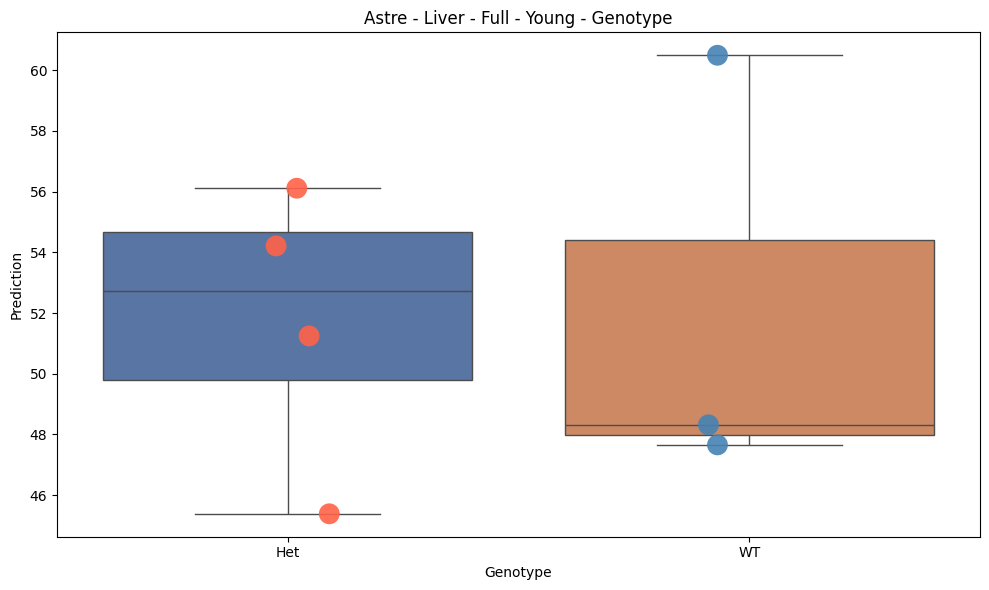

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_full_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_full_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Full - Young - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_full_old = df_prediction_astre_feeding_full[df_prediction_astre_feeding_full["age"] == 105.0]

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

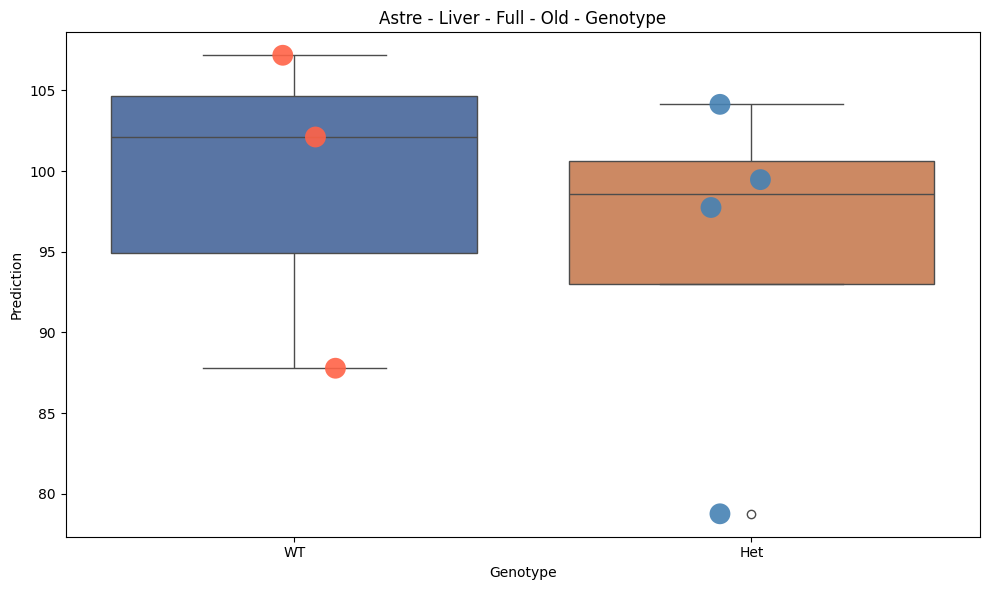

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_full_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_full_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Full - Old - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_fasted = df_prediction_astre[df_prediction_astre["feeding"] == "fasted"]

df_prediction_astre_feeding_fasted.head(5)

,y_pred,age,feeding,genotype
SRR17215660,109.302797,105.0,fasted,WT
SRR17215661,103.634802,105.0,fasted,WT
SRR17215662,94.126950,105.0,fasted,WT
SRR17215663,102.968141,105.0,fasted,Het
SRR17215664,101.896214,105.0,fasted,Het


In [ ]:
df_prediction_astre_feeding_fasted_young = df_prediction_astre_feeding_fasted[df_prediction_astre_feeding_fasted["age"] == 45.5]

df_prediction_astre_feeding_fasted_young.head(3)

,y_pred,age,feeding,genotype
SRR17215666,50.154017,45.5,fasted,WT
SRR17215667,38.363524,45.5,fasted,WT
SRR17215668,53.307850,45.5,fasted,WT


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

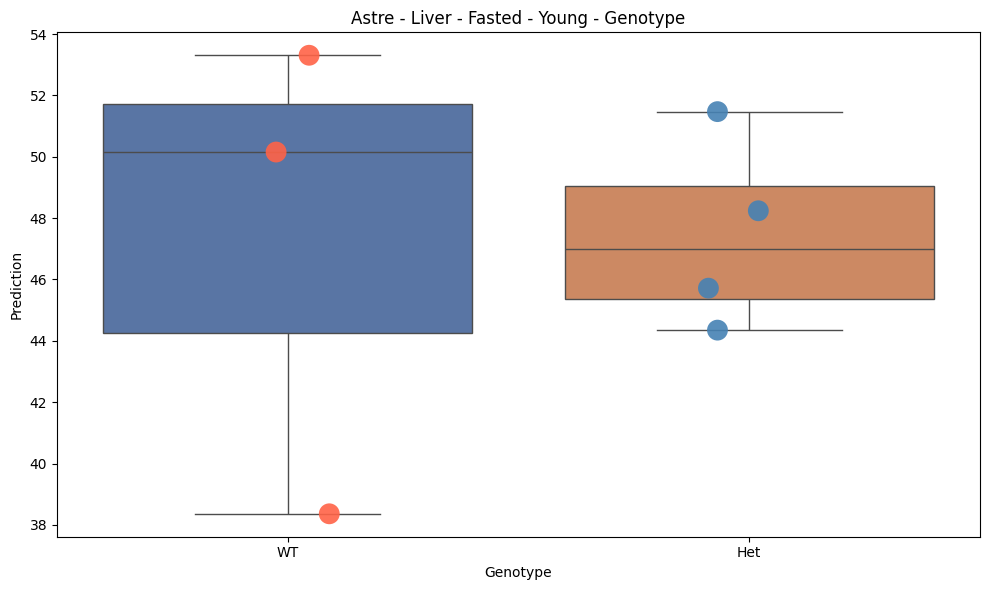

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_fasted_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_fasted_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Fasted - Young - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_fasted_old = df_prediction_astre_feeding_fasted[df_prediction_astre_feeding_fasted["age"] == 105.0]

df_prediction_astre_feeding_fasted_old.head(3)

,y_pred,age,feeding,genotype
SRR17215660,109.302797,105.0,fasted,WT
SRR17215661,103.634802,105.0,fasted,WT
SRR17215662,94.126950,105.0,fasted,WT


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

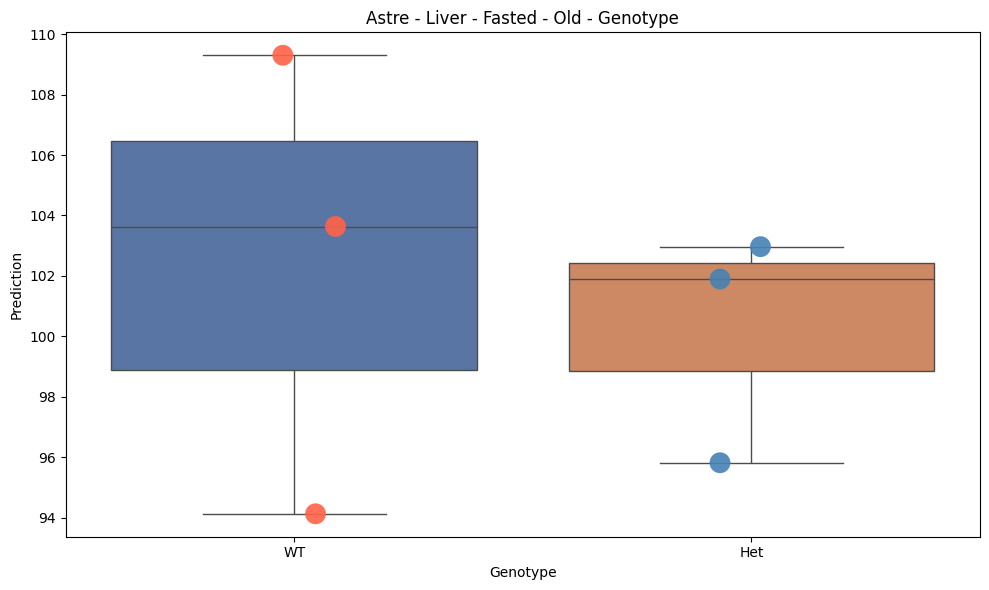

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_fasted_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_fasted_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Fasted - Old - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

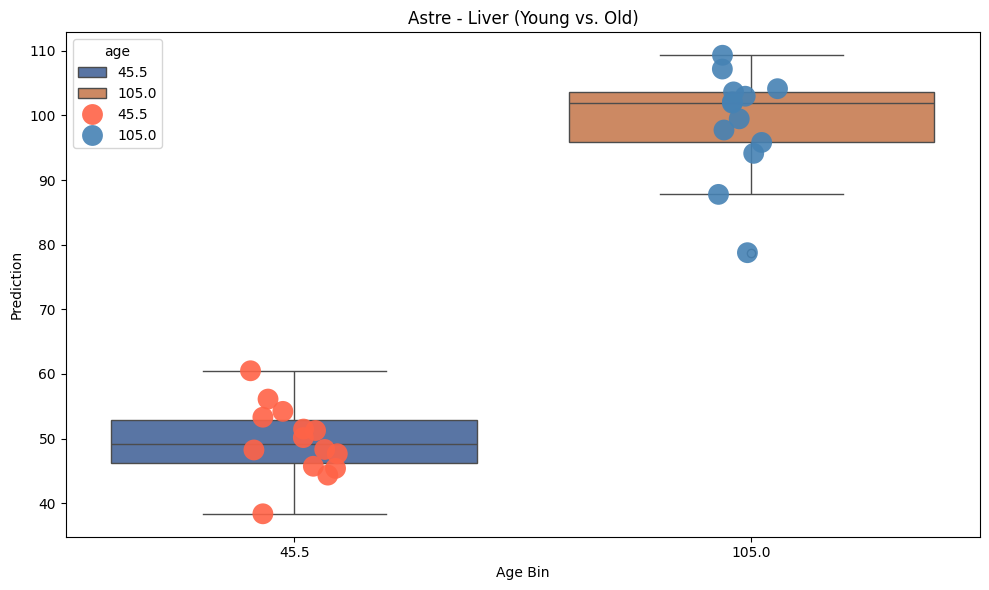

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_astre, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_astre,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_young = df_prediction_astre[df_prediction_astre["age"] == 45.5]

df_prediction_astre_young.head(5)

,y_pred,age,feeding,genotype
SRR17215657,54.209946,45.5,full,Het
SRR17215658,45.387344,45.5,full,Het
SRR17215659,51.245676,45.5,full,Het
SRR17215666,50.154017,45.5,fasted,WT
SRR17215667,38.363524,45.5,fasted,WT


In [ ]:
df_prediction_astre_young

,y_pred,age,feeding,genotype
SRR17215657,54.209946,45.5,full,Het
SRR17215658,45.387344,45.5,full,Het
SRR17215659,51.245676,45.5,full,Het
SRR17215666,50.154017,45.5,fasted,WT
SRR17215667,38.363524,45.5,fasted,WT
SRR17215668,53.307850,45.5,fasted,WT
SRR17215669,48.239780,45.5,fasted,Het
SRR17215670,44.349382,45.5,fasted,Het
SRR17215671,51.470765,45.5,fasted,Het
SRR17215672,45.716675,45.5,fasted,Het


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

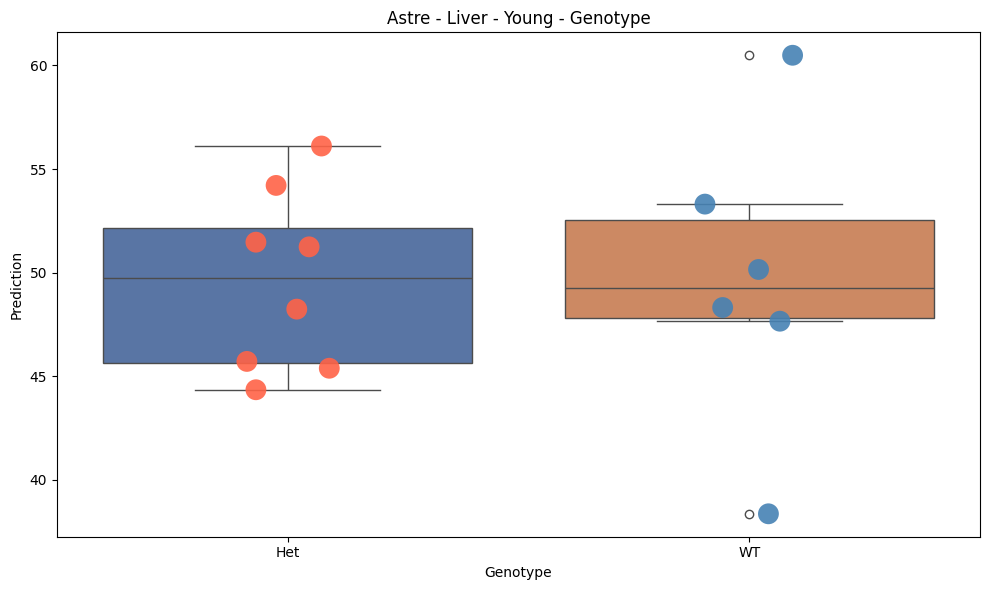

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Young - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

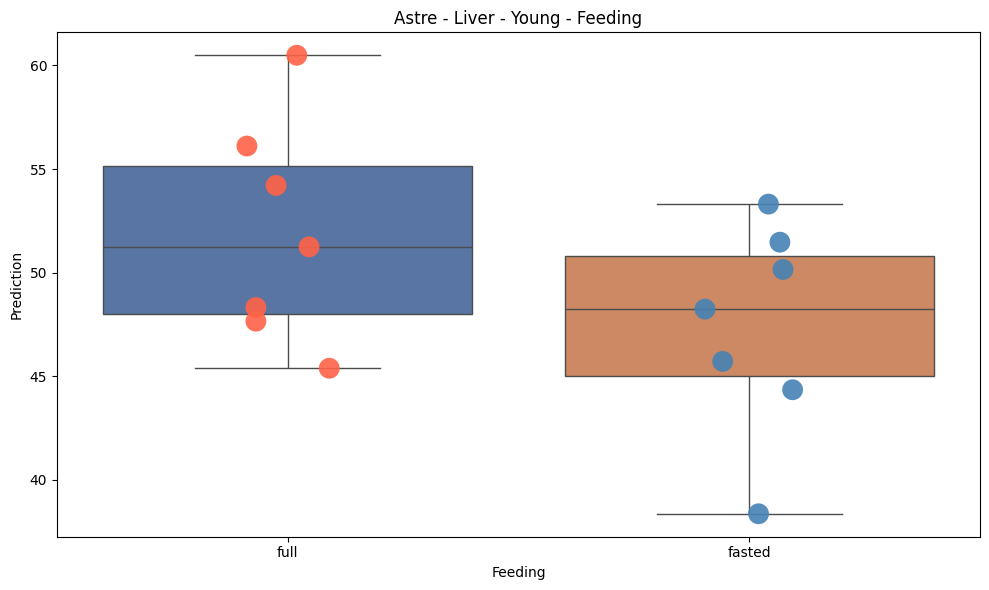

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='feeding', y='y_pred', hue='feeding', data=df_prediction_astre_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='feeding',
    y='y_pred',
    hue='feeding',
    data=df_prediction_astre_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Young - Feeding')
plt.xlabel('Feeding')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_old = df_prediction_astre[df_prediction_astre["age"] == 105]

df_prediction_astre_old.head(5)

,y_pred,age,feeding,genotype
SRR17215646,107.171843,105.0,full,WT
SRR17215660,109.302797,105.0,fasted,WT
SRR17215661,103.634802,105.0,fasted,WT
SRR17215662,94.126950,105.0,fasted,WT
SRR17215663,102.968141,105.0,fasted,Het


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

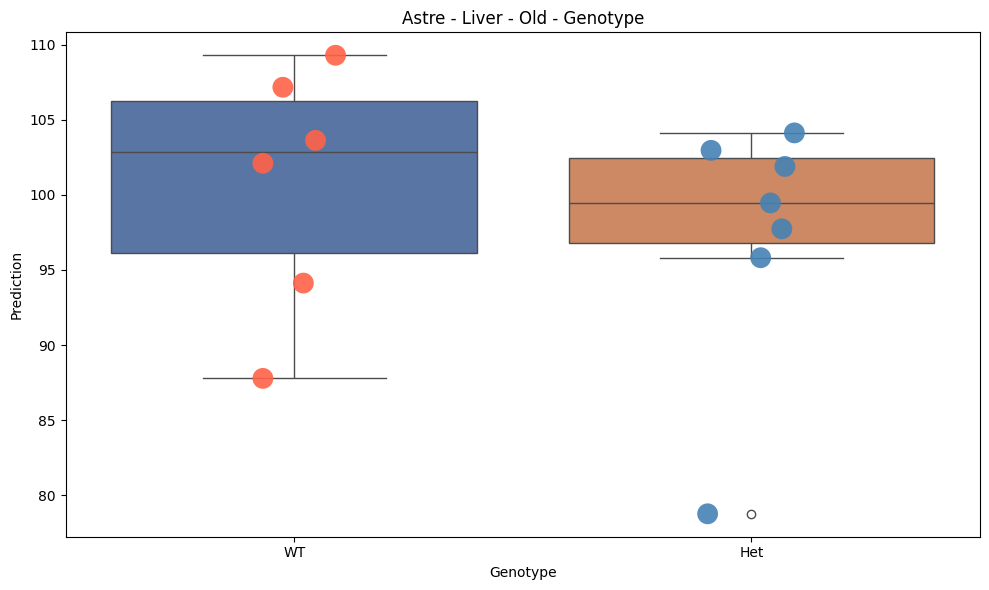

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Old - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

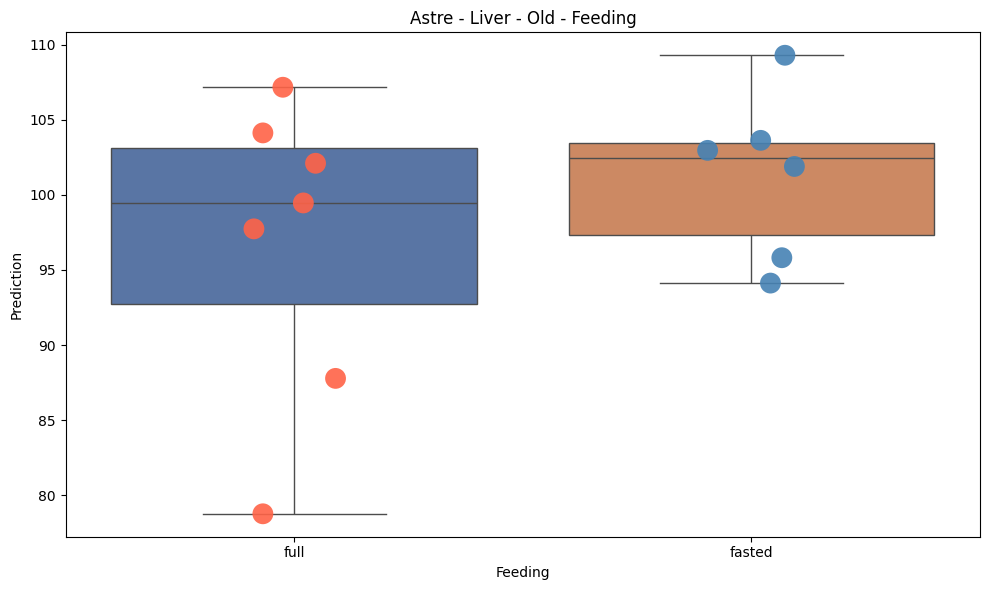

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='feeding', y='y_pred', hue='feeding', data=df_prediction_astre_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='feeding',
    y='y_pred',
    hue='feeding',
    data=df_prediction_astre_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Old - Feeding')
plt.xlabel('Feeding')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

# Sex Combined

In [ ]:
liver_atlas_plus_astre = pd.concat([liver_df_age, df_liver_astre_male_sub], axis=0)

liver_atlas_plus_astre.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,134.0
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,52.0
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,133.0
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,133.0
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,102.0


In [ ]:
liver_atlas_plus_astre.shape

(81, 25123)

In [ ]:
liver_atlas_astre_data = liver_atlas_plus_astre.values

In [ ]:
X, y = liver_atlas_astre_data[:,:-1], liver_atlas_astre_data[:,-1]

In [ ]:
# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Set a seed for reproducibility
seed = 42

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1, return_train_score=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Best parameters

### alpha = 0.1, l1_ratio = 0.8

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 11.825
Pearson correlation: 0.926
R-squared: 0.852
Average number of non-zero coefficients: 215.43


In [ ]:
len(y_pred)

81

In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': liver_atlas_plus_astre["age"].tolist(),
}, index=liver_atlas_plus_astre.index.tolist())

df_prediction.head(10)

,y_pred,age
A5_1,117.267848,134.0
A6_1,54.459736,52.0
A7_1,100.071989,133.0
A8_1,117.111208,133.0
B5_1,94.412793,102.0
B6_1,129.439577,134.0
B7_1,131.097476,133.0
B8_1,107.072253,133.0
C5_1,160.775163,162.0
C6_1,84.427964,52.0


In [ ]:
df_prediction_astre = df_prediction.loc[df_liver_astre_male.index.tolist(), ]

df_prediction_astre.head(5)

,y_pred,age
SRR17215646,106.315010,105.0
SRR17215657,57.988897,45.5
SRR17215658,50.367463,45.5
SRR17215659,54.280921,45.5
SRR17215660,107.392639,105.0


In [ ]:
df_prediction_astre["feeding"] = df_liver_astre_male["feeding_condition"].tolist()
df_prediction_astre["genotype"] = df_liver_astre_male["genotype"].tolist()
df_prediction_astre["age"] = df_liver_astre_male["age"].tolist()

df_prediction_astre.head(5)

,y_pred,age,feeding,genotype
SRR17215646,106.315010,105.0,full,WT
SRR17215657,57.988897,45.5,full,Het
SRR17215658,50.367463,45.5,full,Het
SRR17215659,54.280921,45.5,full,Het
SRR17215660,107.392639,105.0,fasted,WT


In [ ]:
df_prediction_astre.to_csv("./Astre_prediction_sex_combined_only.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

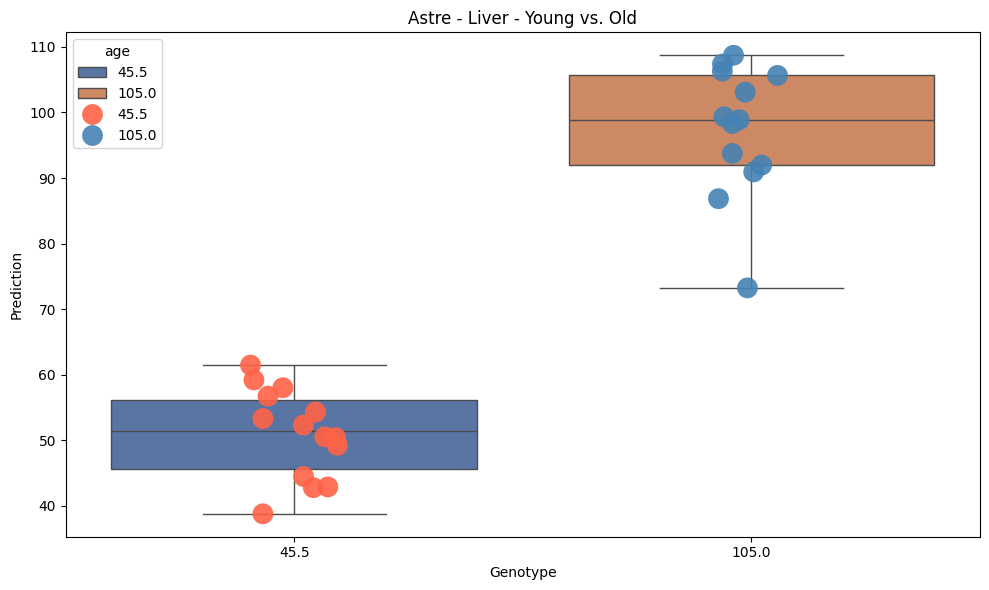

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_astre, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_astre,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Young vs. Old')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_full = df_prediction_astre[df_prediction_astre["feeding"] == "full"]

df_prediction_astre_feeding_full.head(5)

,y_pred,age,feeding,genotype
SRR17215646,106.315010,105.0,full,WT
SRR17215657,57.988897,45.5,full,Het
SRR17215658,50.367463,45.5,full,Het
SRR17215659,54.280921,45.5,full,Het
SRR17215647,86.845250,105.0,full,WT


In [ ]:
df_prediction_astre_feeding_full_young = df_prediction_astre_feeding_full[df_prediction_astre_feeding_full["age"] == 45.5]

df_prediction_astre_feeding_full_young

,y_pred,age,feeding,genotype
SRR17215657,57.988897,45.5,full,Het
SRR17215658,50.367463,45.5,full,Het
SRR17215659,54.280921,45.5,full,Het
SRR17215653,61.440686,45.5,full,WT
SRR17215654,49.203875,45.5,full,WT
SRR17215655,50.497851,45.5,full,WT
SRR17215656,56.711640,45.5,full,Het


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

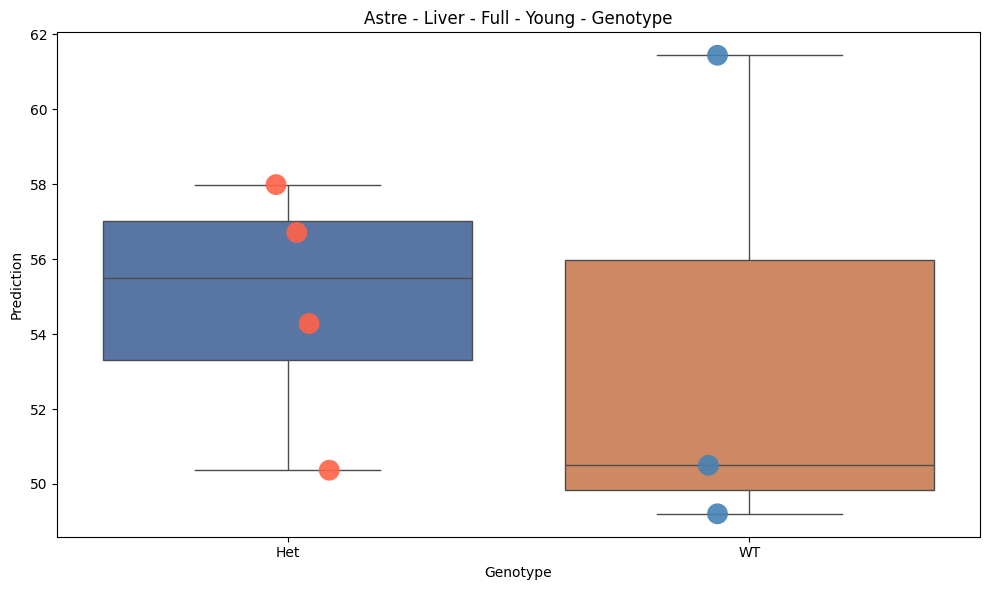

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_full_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_full_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Full - Young - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_full_old = df_prediction_astre_feeding_full[df_prediction_astre_feeding_full["age"] == 105.0]

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

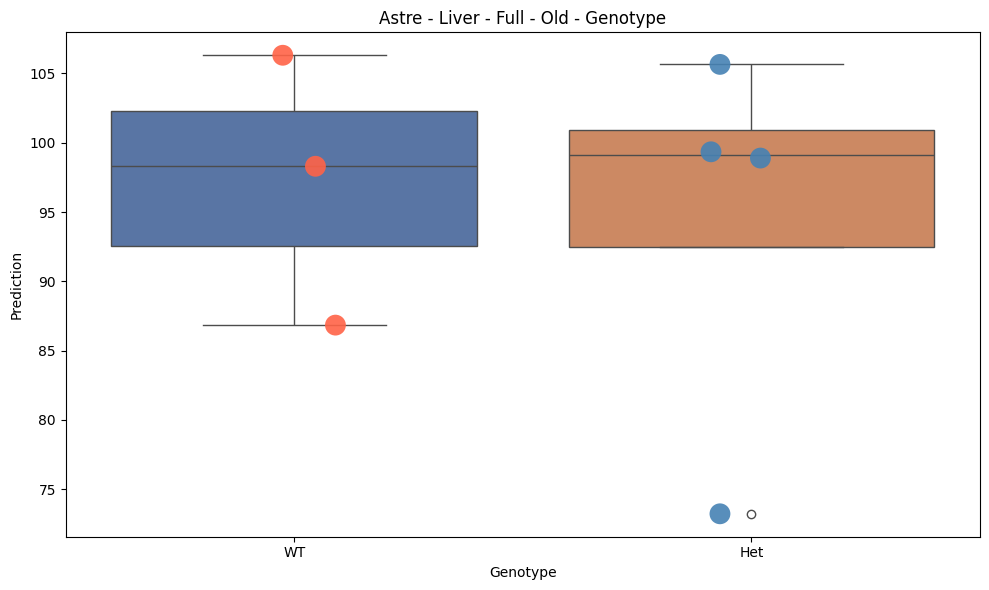

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_full_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_full_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Full - Old - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_fasted = df_prediction_astre[df_prediction_astre["feeding"] == "fasted"]

df_prediction_astre_feeding_fasted.head(5)

,y_pred,age,feeding,genotype
SRR17215660,107.392639,105.0,fasted,WT
SRR17215661,108.735215,105.0,fasted,WT
SRR17215662,90.936037,105.0,fasted,WT
SRR17215663,103.100685,105.0,fasted,Het
SRR17215664,93.746289,105.0,fasted,Het


In [ ]:
df_prediction_astre_feeding_fasted_young = df_prediction_astre_feeding_fasted[df_prediction_astre_feeding_fasted["age"] == 45.5]

df_prediction_astre_feeding_fasted_young.head(3)

,y_pred,age,feeding,genotype
SRR17215666,52.299893,45.5,fasted,WT
SRR17215667,38.752253,45.5,fasted,WT
SRR17215668,53.290969,45.5,fasted,WT


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

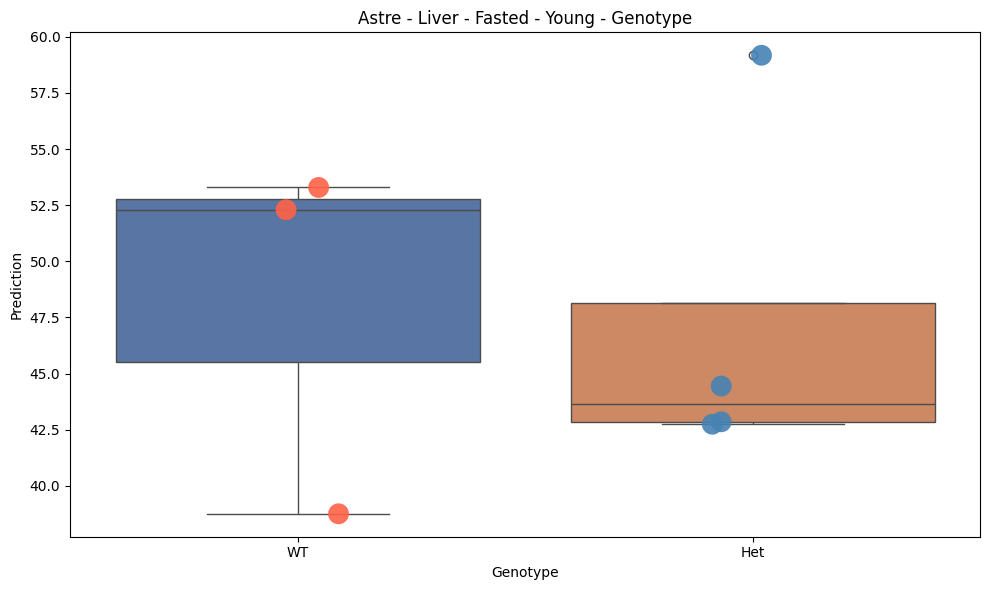

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_fasted_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_fasted_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Fasted - Young - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_astre_feeding_fasted_old = df_prediction_astre_feeding_fasted[df_prediction_astre_feeding_fasted["age"] == 105.0]

df_prediction_astre_feeding_fasted_old.head(3)

,y_pred,age,feeding,genotype
SRR17215660,107.392639,105.0,fasted,WT
SRR17215661,108.735215,105.0,fasted,WT
SRR17215662,90.936037,105.0,fasted,WT


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

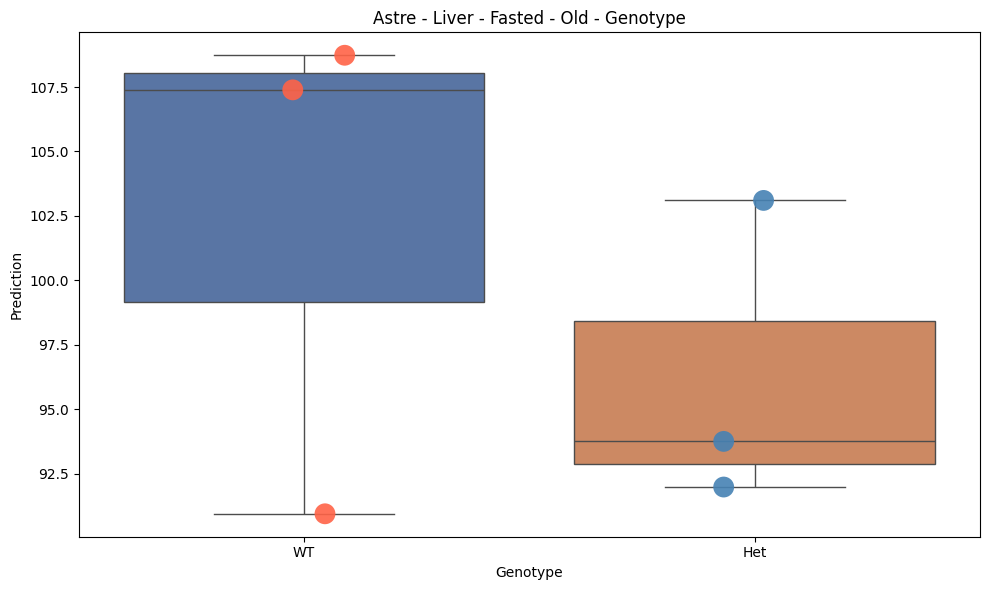

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_astre_feeding_fasted_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_astre_feeding_fasted_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Astre - Liver - Fasted - Old - Genotype')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()